# Auditoria do SINASC 2024 - Fase 0

## tl;dr

- A base oficial contém **2.389.325 registros e 62 colunas**.
- `contador` está completo e é único dentro do arquivo.
- `MESPRENAT` permite a definição diagnóstica candidata de T em **96,613%** dos registros; `99` e missing permanecem fora de T.
- `PESO` é numérico positivo em **99,991%** dos registros; a prevalência bruta diagnóstica de peso < 2.500 g é **9,475%**.
- O gate de dados é **VIÁVEL_COM_RESSALVAS**. Isso não valida causalidade nem autoriza modelagem causal.


## Context & Methods

O objetivo é auditar disponibilidade, granularidade, schema, missing, códigos, tratamento candidato, outcome candidato e temporalidade das covariáveis antes de qualquer modelagem.

### Key Assumptions

- Unidade candidata: um registro de nascido vivo.
- T diagnóstico: `MESPRENAT` de 1 a 3 versus 4 a 9; `99` e missing são excluídos, sem equiparar ausência de pré-natal ao controle.
- Y diagnóstico: `PESO` numérico positivo inferior a 2.500 g.
- O dicionário oficial localizado cobre a estrutura de 1996 a 2019; diferenças em 2024 são explicitadas.
- Classificação de X é provisória por temporalidade, não seleção causal final.


## Data

Fonte: Ministério da Saúde, Portal de Dados Abertos do SUS, recurso **Nascidos Vivos - 2024**. O ZIP bruto, o dicionário e seus hashes estão registrados em `data/raw/source_manifest.json`.


In [1]:
from pathlib import Path
import sys

import duckdb
import pandas as pd
import plotly.express as px
from IPython.display import display

raiz = next(
    candidato
    for candidato in (Path.cwd(), Path.cwd().parent)
    if (candidato / "src").is_dir() and (candidato / "data").is_dir()
).resolve()
sys.path.insert(0, str(raiz))

from src.audita_sinasc_2024 import gerar_auditoria_parquet
from src.visualizacao_ipt import CORES_IPT, aplicar_tema_ipt, configurar_plotly

configurar_plotly()
pd.set_option("display.max_rows", 70)

caminho_parquet = raiz / "data" / "processed" / "sinasc_2024.parquet"
auditoria = gerar_auditoria_parquet(caminho_parquet)
print(f"Parquet carregado: {caminho_parquet}")

Parquet carregado: C:\GitHub\data-science-projects\projetos\big-data-sinasc-causal-ml\data\processed\sinasc_2024.parquet


### 1. Dimensões, granularidade e identificador

In [2]:
resumo_base = pd.DataFrame([
    {
        "registros": auditoria["dimensoes"]["registros"],
        "colunas": auditoria["dimensoes"]["colunas"],
        "granularidade_candidata": auditoria["granularidade_candidata"],
        "identificador": auditoria["identificador"]["coluna"],
        "identificador_unico": auditoria["identificador"]["contador_unico"],
        "duplicados_no_identificador": auditoria["identificador"]["n_duplicados"],
    }
])
display(resumo_base)

,registros,colunas,granularidade_candidata,identificador,identificador_unico,duplicados_no_identificador
0,2389325,62,um registro de nascido vivo,contador,True,0


`contador` é uma chave técnica única nesta extração. O dicionário não garante estabilidade entre versões, portanto ele não deve ser interpretado como identificador longitudinal sem validação adicional.

### 2. Schema auditado

In [3]:
schema = pd.DataFrame(auditoria["schema_auditado"])
display(schema[[
    "coluna", "descricao_oficial", "tipo_observado", "valores_distintos",
    "percentual_missing", "codigos_especiais_documentados",
    "papel_analitico_provisorio", "grupo_temporal_provisorio"
]])

,coluna,descricao_oficial,tipo_observado,valores_distintos,percentual_missing,codigos_especiais_documentados,papel_analitico_provisorio,grupo_temporal_provisorio
0,contador,Número identificador do registro.,texto (VARCHAR; preservado do CSV),2389325,0.000000,NaN,identificador,NaN
1,ORIGEM,Banco de dados de origem.,texto (VARCHAR; preservado do CSV),2,0.000000,NaN,contextual,NaN
2,CODESTAB,Código do estabelecimento de saúde onde ocorre...,texto (VARCHAR; preservado do CSV),5368,0.953073,NaN,ainda não classificado,C. temporalidade ou papel causal duvidoso
3,CODMUNNASC,Código IBGE do município de nascimento.,texto (VARCHAR; preservado do CSV),3829,0.000000,NaN,ainda não classificado,NaN
4,LOCNASC,Local de nascimento.,texto (VARCHAR; preservado do CSV),6,0.000000,NaN,ainda não classificado,C. temporalidade ou papel causal duvidoso
5,IDADEMAE,Idade da mãe.,texto (VARCHAR; preservado do CSV),57,0.000879,NaN,X candidato,A. provavelmente pré-tratamento
6,ESTCIVMAE,Situação conjugal da mãe.,texto (VARCHAR; preservado do CSV),6,0.386050,9=Ignorada,X candidato,A. provavelmente pré-tratamento
7,ESCMAE,"Escolaridade, em anos de estudo concluídos.",texto (VARCHAR; preservado do CSV),6,0.325908,9=Ignorado,X candidato,A. provavelmente pré-tratamento
8,CODOCUPMAE,Código de ocupação da mãe conforme a CBO.,texto (VARCHAR; preservado do CSV),2048,6.483421,NaN,ainda não classificado,C. temporalidade ou papel causal duvidoso
9,QTDFILVIVO,Número de filhos vivos.,texto (VARCHAR; preservado do CSV),23,1.248679,NaN,X candidato,A. provavelmente pré-tratamento


### 3. Missing

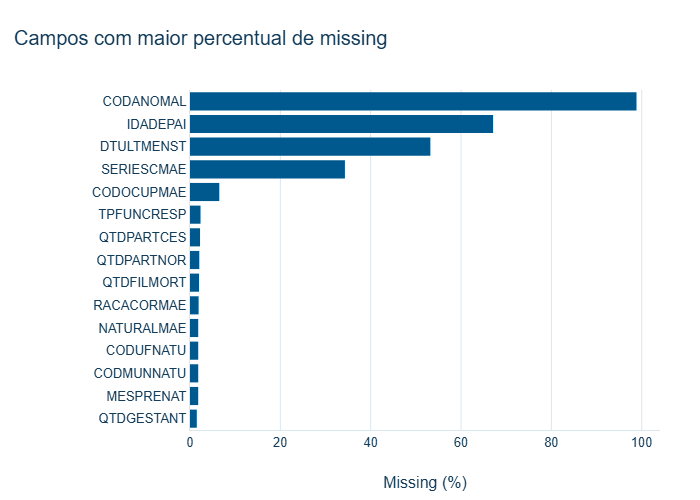

,coluna,n_missing,percentual_missing
0,CODANOMAL,2361762,98.846411
1,IDADEPAI,1603365,67.105354
2,DTULTMENST,1271415,53.212309
3,SERIESCMAE,819455,34.296506
4,CODOCUPMAE,154910,6.483421
5,TPFUNCRESP,55704,2.331370
6,QTDPARTCES,53138,2.223975
7,QTDPARTNOR,49125,2.056020
8,QTDFILMORT,47818,2.001318
9,RACACORMAE,45610,1.908907


In [4]:
missing = pd.DataFrame(auditoria["principais_campos_missing"]).sort_values("percentual_missing")
fig_missing = px.bar(
    missing,
    x="percentual_missing",
    y="coluna",
    orientation="h",
    labels={"percentual_missing": "Missing (%)", "coluna": "Campo"},
)
fig_missing.update_traces(marker_color=CORES_IPT["AZUL_PRINCIPAL"])
fig_missing.update_xaxes(rangemode="tozero")
fig_missing.update_yaxes(title_text=None, automargin=True)
aplicar_tema_ipt(fig_missing, "Campos com maior percentual de missing")
fig_missing.update_layout(margin={"l": 190, "r": 40, "t": 90, "b": 70})
fig_missing.write_image(raiz / "outputs" / "figures" / "missing_sinasc_2024.png", width=1200, height=780, scale=1.5)
fig_missing.show()
display(missing.sort_values("percentual_missing", ascending=False))

`CODANOMAL` tem missing estrutural esperado quando não há anomalia; `IDADEPAI`, `DTULTMENST` e `SERIESCMAE` apresentam perdas materiais para eventual ajuste. Missing deve ser interpretado por semântica, não apenas por ranking.

## Results

### 4. Tratamento candidato

,0
coluna,MESPRENAT
semantica_oficial,Mês de gestação em que iniciou o pré-natal.
n_total,2389325
n_utilizavel,2308388
percentual_utilizavel,96.612558
n_inicio_ate_terceiro_mes,1992408
n_inicio_apos_terceiro_mes,315980
n_codigo_99,37569
n_missing,43368
n_outros_invalidos,0


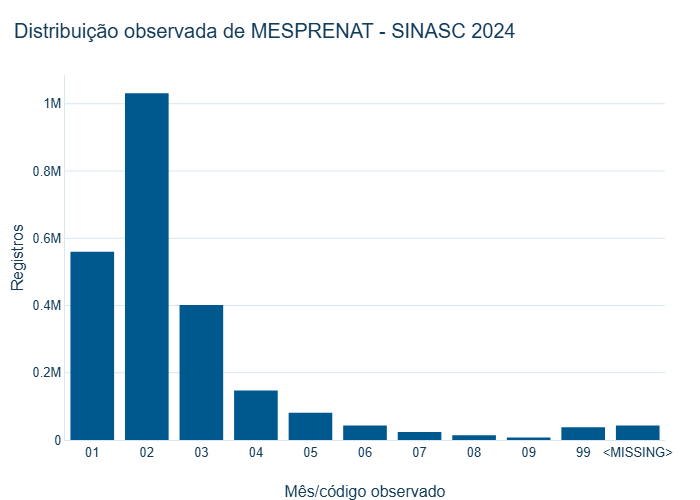

In [5]:
tratamento = auditoria["tratamento_candidato"]
display(pd.DataFrame([{chave: valor for chave, valor in tratamento.items() if chave != "dominio_observado"}]).T)

dominio_t = pd.DataFrame(
    [{"mes": mes, "registros": n} for mes, n in tratamento["dominio_observado"].items()]
)
ordem_t = [f"{mes:02d}" for mes in range(1, 10)] + ["99", "<MISSING>"]
dominio_t["mes"] = pd.Categorical(dominio_t["mes"], categories=ordem_t, ordered=True)
dominio_t = dominio_t.sort_values("mes")
fig_t = px.bar(
    dominio_t,
    x="mes",
    y="registros",
    category_orders={"mes": ordem_t},
    labels={"mes": "Mês/código observado", "registros": "Registros"},
)
fig_t.update_traces(marker_color=CORES_IPT["AZUL_PRINCIPAL"])
fig_t.update_xaxes(type="category")
aplicar_tema_ipt(fig_t, "Distribuição observada de MESPRENAT - SINASC 2024")
fig_t.write_image(raiz / "outputs" / "figures" / "mesprenat_sinasc_2024.png", width=1200, height=680, scale=1.5)
fig_t.show()

A definição candidata é tecnicamente construível para meses 1-9. O código `99` é observado, mas não está documentado no PDF 1996-2019; ele fica excluído de T e registrado como `QUESTAO_ABERTA`. Não há código 00/10 observado nesta extração, e nenhuma ausência de pré-natal é convertida automaticamente em controle.

### 5. Outcome candidato

,0
coluna,PESO
semantica_oficial,Peso ao nascer em gramas.
unidade,gramas
n_total,2389325
n_valido,2389104
percentual_valido,99.990751
n_baixo_peso,226375
prevalencia_baixo_peso_percentual,9.47531
n_missing_invalido,221
peso_minimo_gramas,100.0


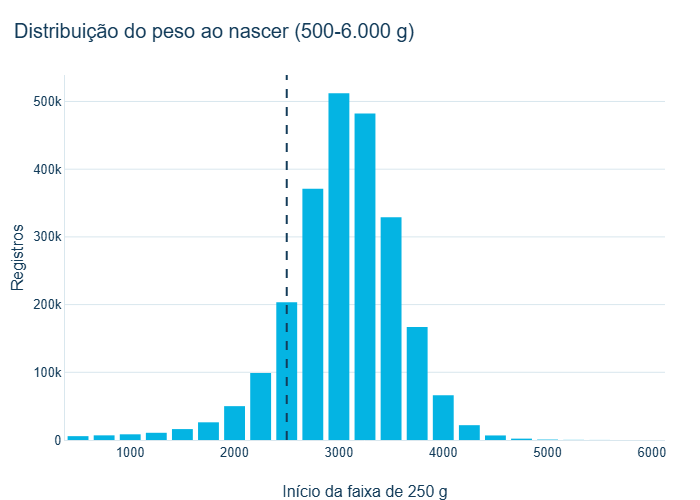

In [6]:
outcome = auditoria["outcome_candidato"]
display(pd.DataFrame([outcome]).T)

caminho_sql = caminho_parquet.as_posix().replace("'", "''")
distribuicao_peso = duckdb.sql(f"""
    WITH pesos AS (
        SELECT try_cast(PESO AS INTEGER) AS peso
        FROM read_parquet('{caminho_sql}')
    )
    SELECT floor(peso / 250) * 250 AS inicio_faixa_g, count(*) AS registros
    FROM pesos
    WHERE peso BETWEEN 500 AND 6000
    GROUP BY 1
    ORDER BY 1
""").df()
fig_peso = px.bar(
    distribuicao_peso,
    x="inicio_faixa_g",
    y="registros",
    labels={"inicio_faixa_g": "Início da faixa de 250 g", "registros": "Registros"},
)
fig_peso.update_traces(marker_color=CORES_IPT["CIANO"])
fig_peso.add_vline(x=2500, line_dash="dash", line_color=CORES_IPT["AZUL_ESCURO"])
aplicar_tema_ipt(fig_peso, "Distribuição do peso ao nascer (500-6.000 g)")
fig_peso.write_image(raiz / "outputs" / "figures" / "peso_sinasc_2024.png", width=1200, height=680, scale=1.5)
fig_peso.show()


A linha em 2.500 g representa apenas o limiar diagnóstico de baixo peso. Os 3.727 registros abaixo de 500 g e os 59 acima de 6.000 g são alertas de qualidade, não exclusões automáticas.

### 6. Covariáveis candidatas e risco de leakage

In [7]:
grupos = auditoria["covariaveis_por_temporalidade"]
mapa_temporal = pd.DataFrame(
    [
        {"grupo": grupo, "campo": campo}
        for grupo, campos in grupos.items()
        for campo in campos
    ]
)
display(mapa_temporal)

,grupo,campo
0,A_provavelmente_pre_tratamento,CODMUNNATU
1,A_provavelmente_pre_tratamento,CODMUNRES
2,A_provavelmente_pre_tratamento,CODPAISRES
3,A_provavelmente_pre_tratamento,CODUFNATU
4,A_provavelmente_pre_tratamento,DTNASCMAE
5,A_provavelmente_pre_tratamento,ESCMAE
6,A_provavelmente_pre_tratamento,ESCMAE2010
7,A_provavelmente_pre_tratamento,ESCMAEAGR1
8,A_provavelmente_pre_tratamento,ESTCIVMAE
9,A_provavelmente_pre_tratamento,IDADEMAE


O grupo A contém variáveis plausivelmente anteriores ao início do pré-natal, mas isso **não** as transforma automaticamente em confundidores. O grupo B inclui número de consultas, idade gestacional, parto, Apgar, características neonatais e índice de Kotelchuck; usá-las como ajuste pode introduzir leakage ou bloquear mediação. O grupo C exige validação causal/temporal manual.

## Takeaways

- Volume, schema e identificador técnico são adequados para prosseguir com desenho metodológico.
- T e Y candidatos podem ser construídos para a grande maioria da base.
- Missing em T e em covariáveis específicas precisa de estratégia explícita.
- A documentação localizada não é específica de 2024.
- Nenhuma variável X foi congelada e nenhuma estimativa causal foi executada.

## Gate de viabilidade

**VIÁVEL_COM_RESSALVAS**

Os dados permitem avançar para uma Fase 1 de desenho causal, mas o avanço deve resolver o código 99 de `MESPRENAT`, regras de qualidade de peso, missing, temporalidade de X e uma estratégia de identificação defensável. Este gate avalia os dados e o desenho candidato; não valida causalidade.
